In [1]:
!pip install xgboost lightgbm --quiet
!pip install scikit-learn==1.5.2 --quiet
print("완료!")

완료!


In [2]:
import warnings
warnings.filterwarnings("ignore")
from os.path import join
import pandas as pd
import numpy as np
import lightgbm as lgb

# 데이터
data_dir = '~/work/kaggle_kakr_housing/data'
train = pd.read_csv(join(data_dir, 'train.csv'))
test  = pd.read_csv(join(data_dir, 'test.csv'))
sub   = pd.read_csv(join(data_dir, 'sample_submission.csv'))

# 날짜 변환
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date']  = test['date'].apply(lambda i: i[:6]).astype(int)

# id 저장 후 삭제
sub_id = test['id']
del train['id']
del test['id']

# y 분리 + log 변환
y = np.log1p(train['price'])
del train['price']

# 모델 학습
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    random_state=2019
)
model.fit(train, y)

# 예측 + 역변환
prediction = np.expm1(model.predict(test))

# 제출 파일 저장
result = pd.DataFrame({'id': sub_id, 'price': prediction})
result.to_csv(join(data_dir, 'submission_final.csv'), index=False)
print("완료!")
print(result.head())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001616 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
완료!
      id         price
0  15035  4.762408e+05
1  15036  4.849037e+05
2  15037  1.386226e+06
3  15038  2.987208e+05
4  15039  3.262536e+05


In [4]:
!pip install xgboost lightgbm --quiet
!pip install scikit-learn==1.5.2 --quiet
print("설치 완료!")

설치 완료!


In [5]:
import warnings
warnings.filterwarnings("ignore")
from os.path import join
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
print("얍💢")


얍💢


In [6]:
data_dir = '~/work/kaggle_kakr_housing/data'
train = pd.read_csv(join(data_dir, 'train.csv'))
test  = pd.read_csv(join(data_dir, 'test.csv'))
sub   = pd.read_csv(join(data_dir, 'sample_submission.csv'))

print(train.shape, test.shape)
train.head()

(15035, 21) (6468, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [7]:
# 날짜 변환
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date']  = test['date'].apply(lambda i: i[:6]).astype(int)

# id 저장
sub_id = test['id']
del train['id']
del test['id']

# y 분리 + log 변환
y = np.log1p(train['price'])
del train['price']

print("전처리 완료!")
print(train.shape)

전처리 완료!
(15035, 19)


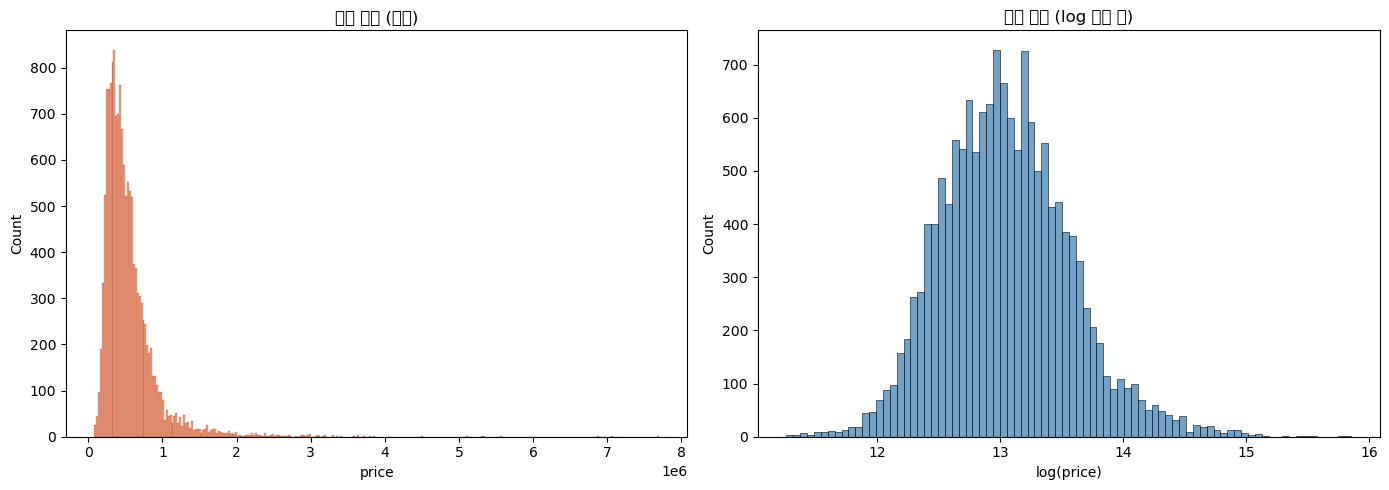

log 변환으로 정규분포에 가까워졌어요!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 변환 전
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')

# 변환 후
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')

plt.tight_layout()
plt.show()
print("log 변환으로 정규분포에 가까워졌어요!")

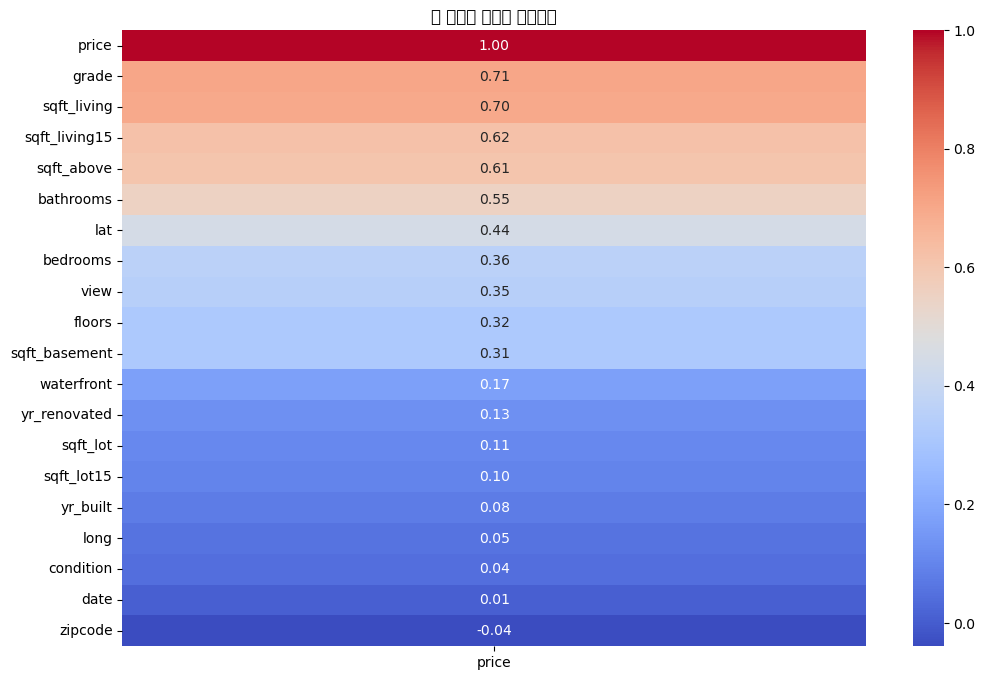

In [9]:
plt.figure(figsize=(12, 8))
corr = pd.concat([train, y], axis=1).corr()
sns.heatmap(corr[['price']].sort_values('price', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('각 변수와 집값의 상관관계')
plt.show()

In [10]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    random_state=2019
)
model.fit(train, y)
print("학습 완료!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
학습 완료!


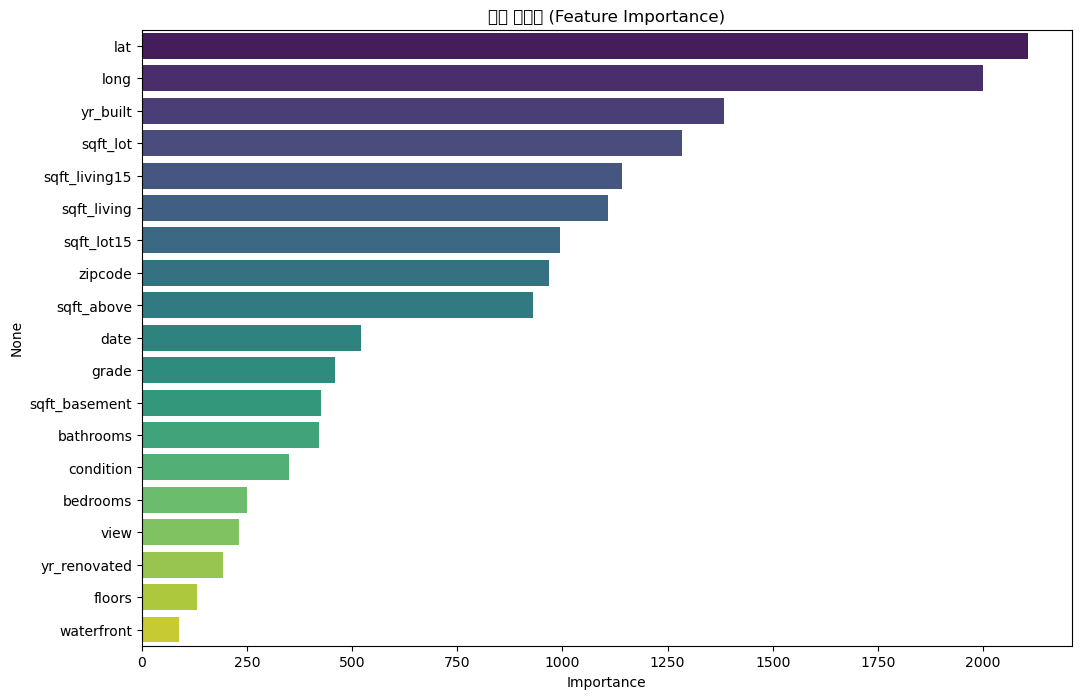

In [11]:
plt.figure(figsize=(12, 8))
feat_imp = pd.Series(model.feature_importances_,
                     index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('변수 중요도 (Feature Importance)')
plt.xlabel('Importance')
plt.show()

In [12]:
prediction = np.expm1(model.predict(test))

result = pd.DataFrame({'id': sub_id, 'price': prediction})
save_path = join(data_dir, 'submission_lgbm.csv')
result.to_csv(save_path, index=False)

print("제출 파일 저장 완료!")
print(save_path)
print(result.head())

제출 파일 저장 완료!
~/work/kaggle_kakr_housing/data/submission_lgbm.csv
      id         price
0  15035  4.762408e+05
1  15036  4.849037e+05
2  15037  1.386226e+06
3  15038  2.987208e+05
4  15039  3.262536e+05


In [13]:
!cp ~/work/kaggle_kakr_housing/data/submission_lgbm.csv ~/work/submission_lgbm.csv
print("복사 완료!")

복사 완료!


In [14]:
model2 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=50,
    min_child_samples=20,
    random_state=2019
)
model2.fit(train, y)

prediction2 = np.expm1(model2.predict(test))
result2 = pd.DataFrame({'id': sub_id, 'price': prediction2})
save_path2 = join(data_dir, 'submission_lgbm2.csv')
result2.to_csv(save_path2, index=False)
print("완료!")
print(result2.head())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

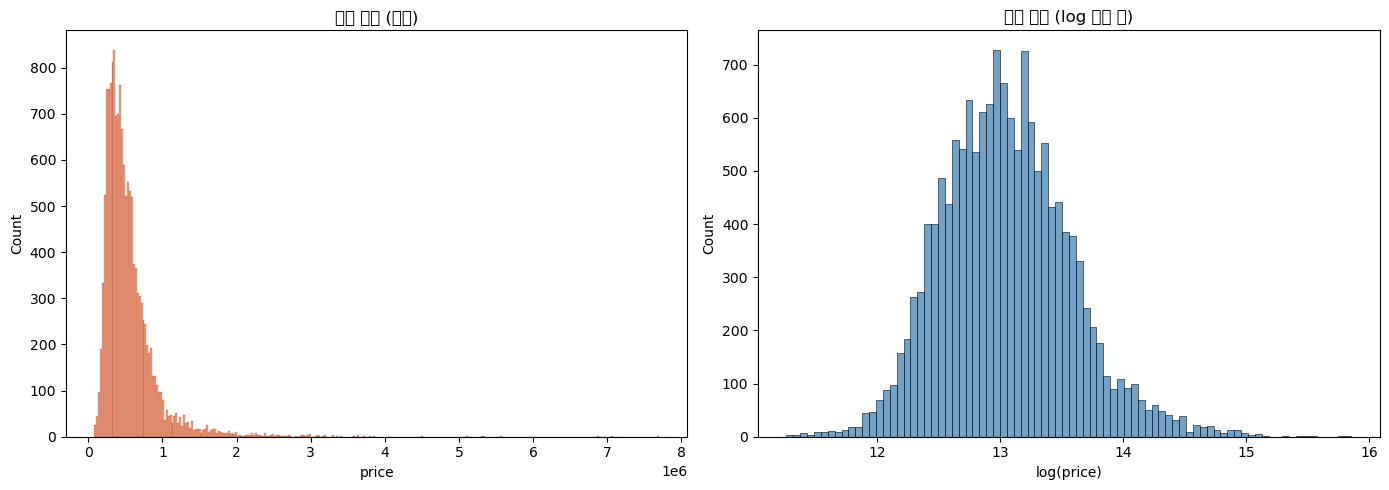

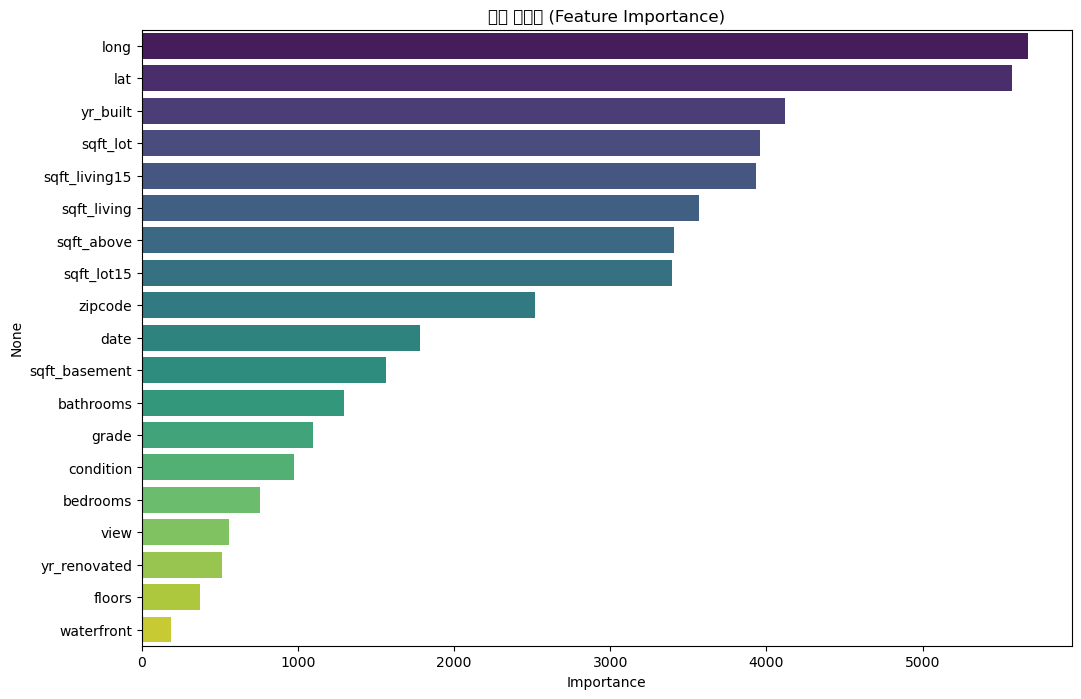

파일 복사 완료!


In [16]:
# 그래프 1: 집값 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: 변수 중요도
plt.figure(figsize=(12, 8))
feat_imp = pd.Series(model2.feature_importances_,
                     index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('변수 중요도 (Feature Importance)')
plt.xlabel('Importance')
plt.show()

# 파일 복사
!cp ~/work/kaggle_kakr_housing/data/submission_lgbm2.csv ~/work/submission_lgbm2.csv
print("파일 복사 완료!")

In [17]:
model3 = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=63,
    min_child_samples=25,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2019
)
model3.fit(train, y)

prediction3 = np.expm1(model3.predict(test))
result3 = pd.DataFrame({'id': sub_id, 'price': prediction3})
result3.to_csv(join(data_dir, 'submission_lgbm3.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_lgbm3.csv ~/work/submission_lgbm3.csv
print("완료!")
print(result3.head())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

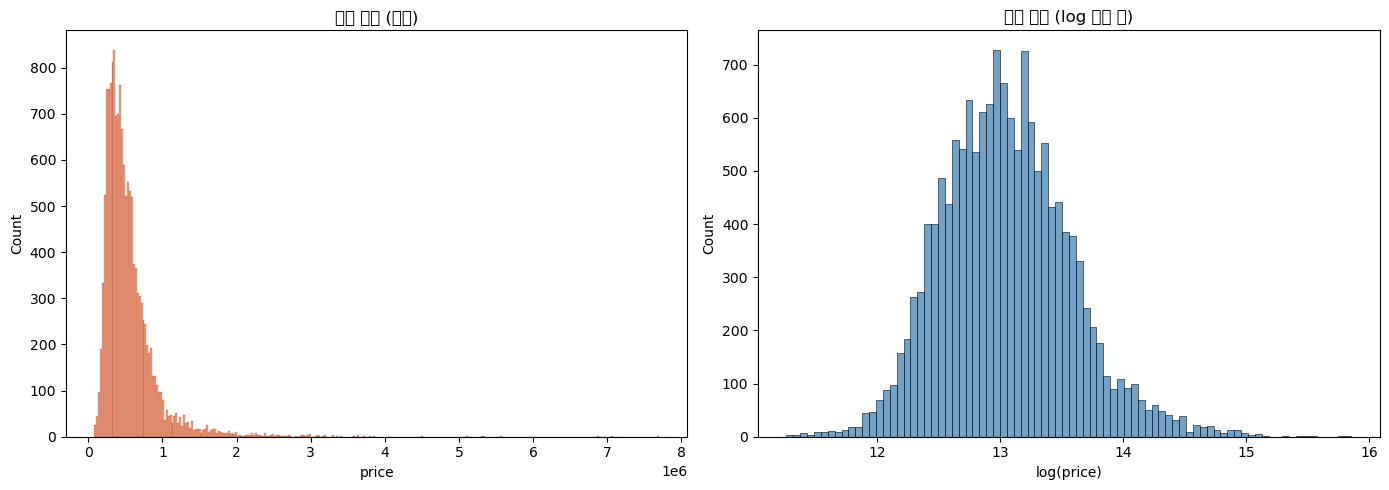

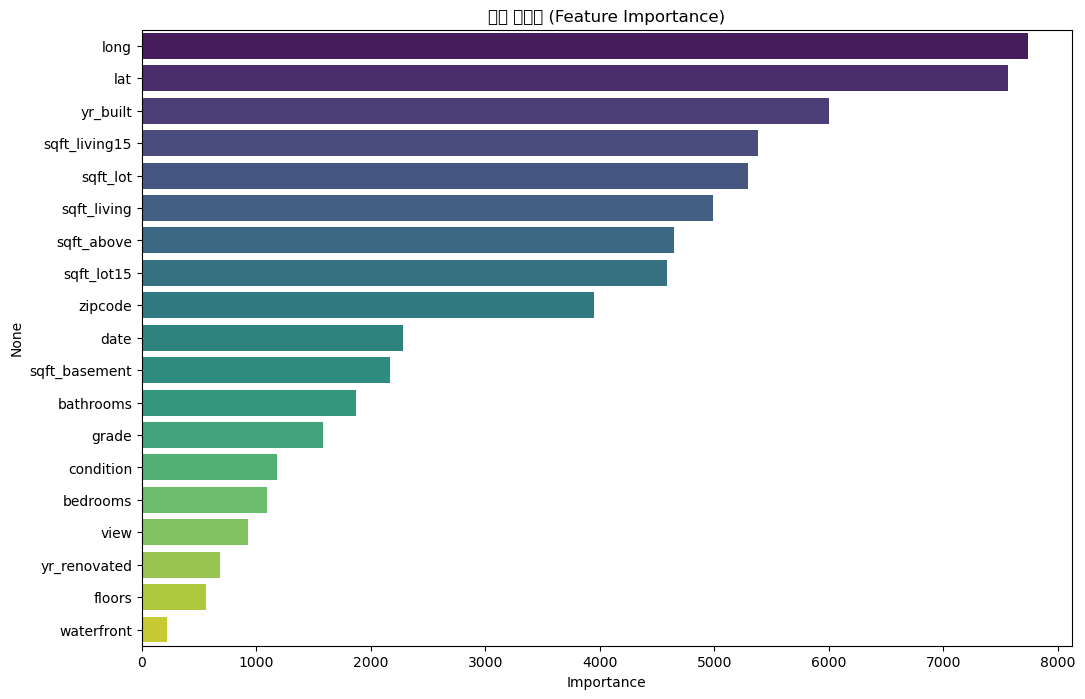

완료!
      id         price
0  15035  5.102039e+05
1  15036  4.974095e+05
2  15037  1.354235e+06
3  15038  2.949198e+05
4  15039  3.288912e+05


In [18]:
# 모델 학습
model3 = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=63,
    min_child_samples=25,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2019
)
model3.fit(train, y)

# 그래프 1: 집값 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: 변수 중요도
plt.figure(figsize=(12, 8))
feat_imp = pd.Series(model3.feature_importances_,
                     index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('변수 중요도 (Feature Importance)')
plt.xlabel('Importance')
plt.show()

# 예측 + 저장
prediction3 = np.expm1(model3.predict(test))
result3 = pd.DataFrame({'id': sub_id, 'price': prediction3})
result3.to_csv(join(data_dir, 'submission_lgbm3.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_lgbm3.csv ~/work/submission_lgbm3.csv
print("완료!")
print(result3.head())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

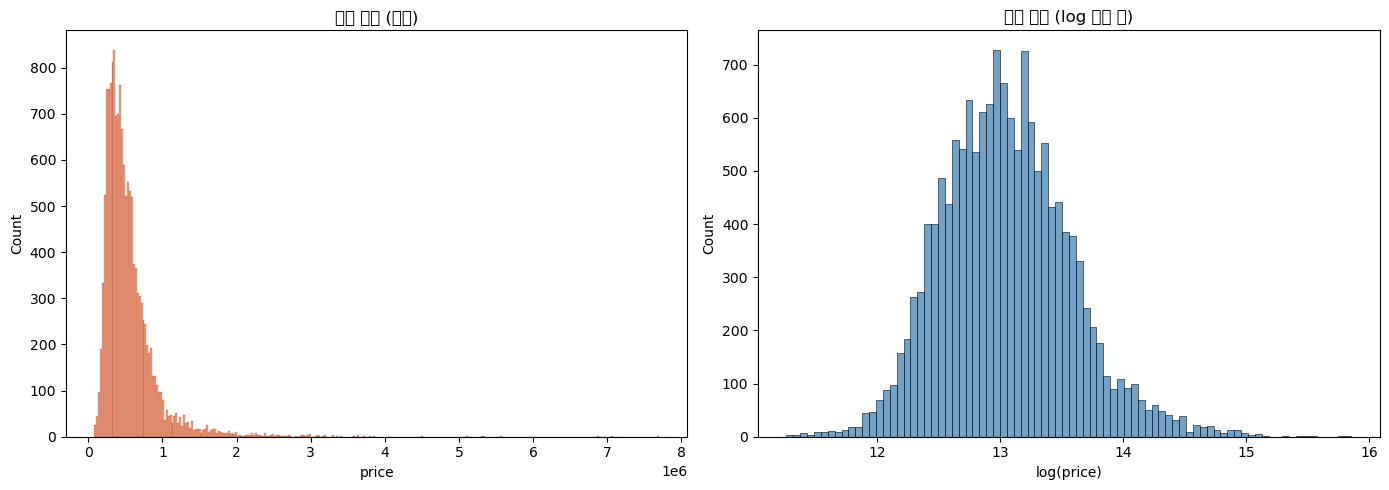

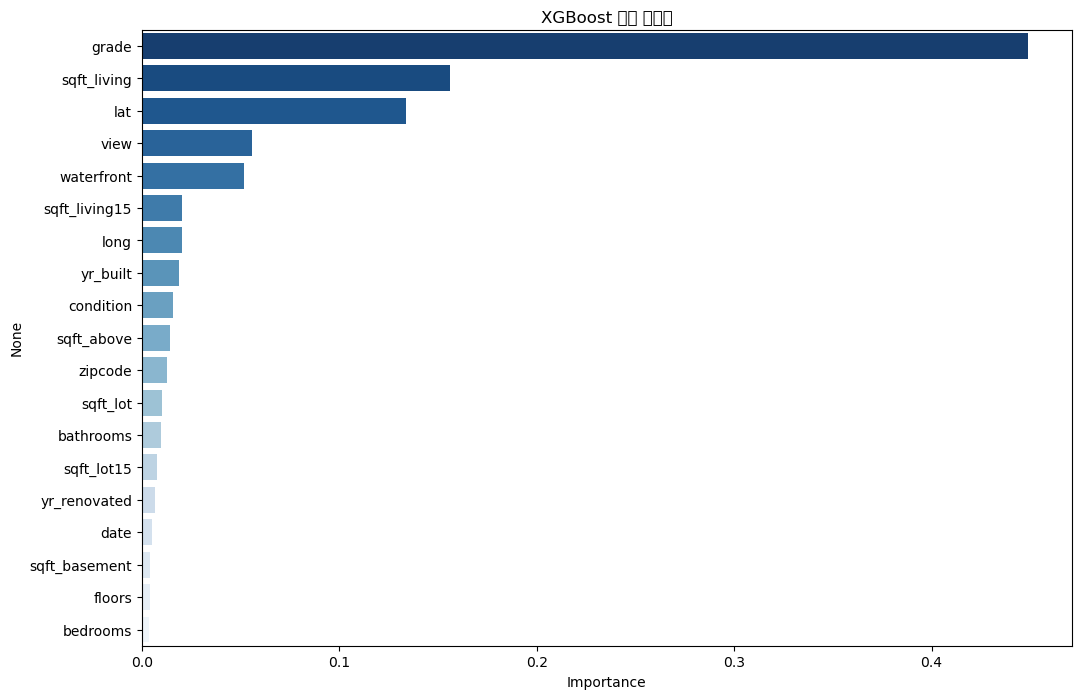

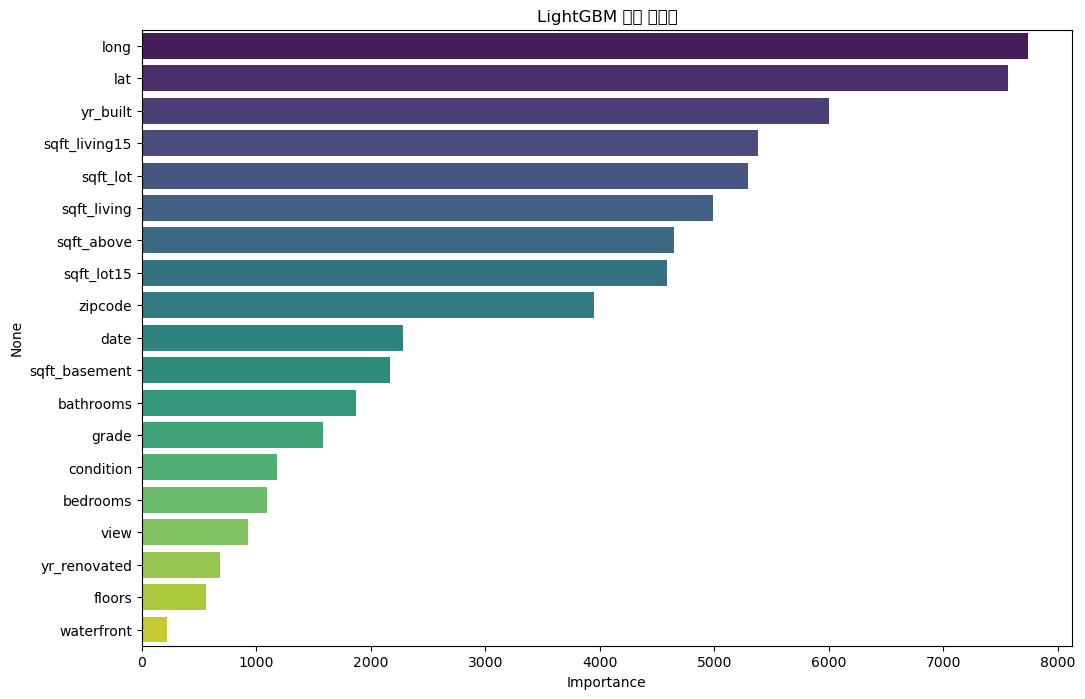

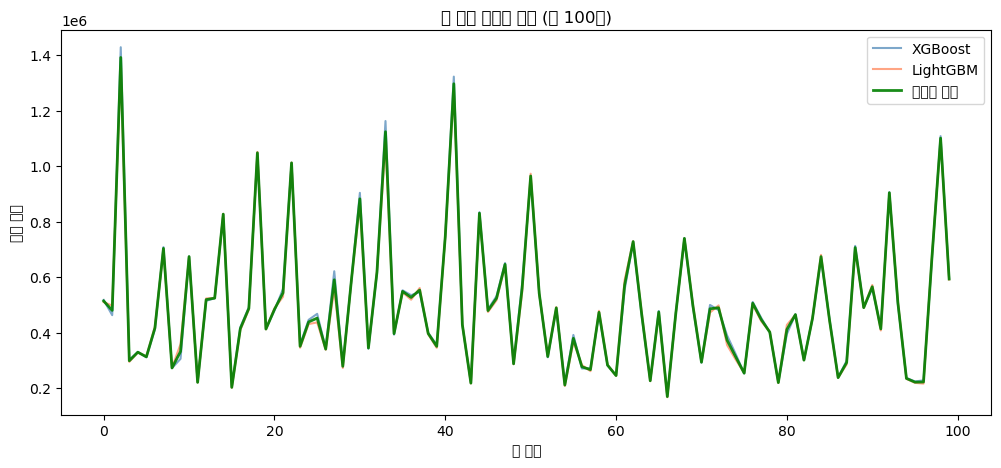

앙상블 완료!
      id         price
0  15035  5.140369e+05
1  15036  4.801800e+05
2  15037  1.391137e+06
3  15038  2.986920e+05
4  15039  3.296643e+05


In [19]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

# XGBoost 모델
model_xgb = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2019
)
model_xgb.fit(train, y)

# LightGBM 모델
model_lgb = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=63,
    min_child_samples=25,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2019
)
model_lgb.fit(train, y)

# 그래프 1: 집값 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: XGBoost 변수 중요도
plt.figure(figsize=(12, 8))
feat_imp_xgb = pd.Series(model_xgb.feature_importances_,
                          index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp_xgb.values, y=feat_imp_xgb.index, palette='Blues_r')
plt.title('XGBoost 변수 중요도')
plt.xlabel('Importance')
plt.show()

# 그래프 3: LightGBM 변수 중요도
plt.figure(figsize=(12, 8))
feat_imp_lgb = pd.Series(model_lgb.feature_importances_,
                          index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp_lgb.values, y=feat_imp_lgb.index, palette='viridis')
plt.title('LightGBM 변수 중요도')
plt.xlabel('Importance')
plt.show()

# 앙상블! 두 모델 평균
pred_xgb = np.expm1(model_xgb.predict(test))
pred_lgb = np.expm1(model_lgb.predict(test))
pred_ensemble = (pred_xgb + pred_lgb) / 2

# 그래프 4: 두 모델 예측값 비교
plt.figure(figsize=(12, 5))
plt.plot(pred_xgb[:100], label='XGBoost', alpha=0.7, color='steelblue')
plt.plot(pred_lgb[:100], label='LightGBM', alpha=0.7, color='coral')
plt.plot(pred_ensemble[:100], label='앙상블 평균', alpha=0.9,
         color='green', linewidth=2)
plt.title('두 모델 예측값 비교 (앞 100개)')
plt.xlabel('집 번호')
plt.ylabel('예측 집값')
plt.legend()
plt.show()

# 저장
result4 = pd.DataFrame({'id': sub_id, 'price': pred_ensemble})
result4.to_csv(join(data_dir, 'submission_ensemble.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_ensemble.csv ~/work/submission_ensemble.csv
print("앙상블 완료!")
print(result4.head())

In [20]:
# GradientBoosting 추가해서 3개 앙상블!
from sklearn.ensemble import GradientBoostingRegressor

model_gbm = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=2019
)
model_gbm.fit(train, y)

# 3개 모델 평균
pred_xgb = np.expm1(model_xgb.predict(test))
pred_lgb = np.expm1(model_lgb.predict(test))
pred_gbm = np.expm1(model_gbm.predict(test))
pred_final = (pred_xgb + pred_lgb + pred_gbm) / 3

# 저장
result5 = pd.DataFrame({'id': sub_id, 'price': pred_final})
result5.to_csv(join(data_dir, 'submission_final3.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_final3.csv ~/work/submission_final3.csv
print("3개 앙상블 완료!")
print(result5.head())

3개 앙상블 완료!
      id         price
0  15035  5.173305e+05
1  15036  4.665905e+05
2  15037  1.405275e+06
3  15038  3.073711e+05
4  15039  3.264209e+05


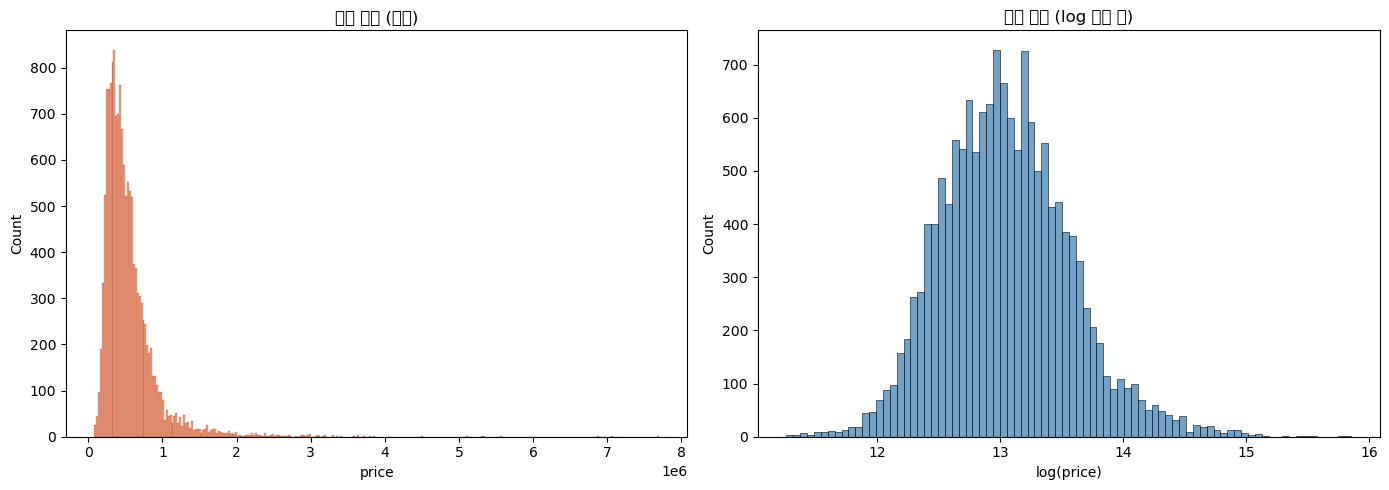

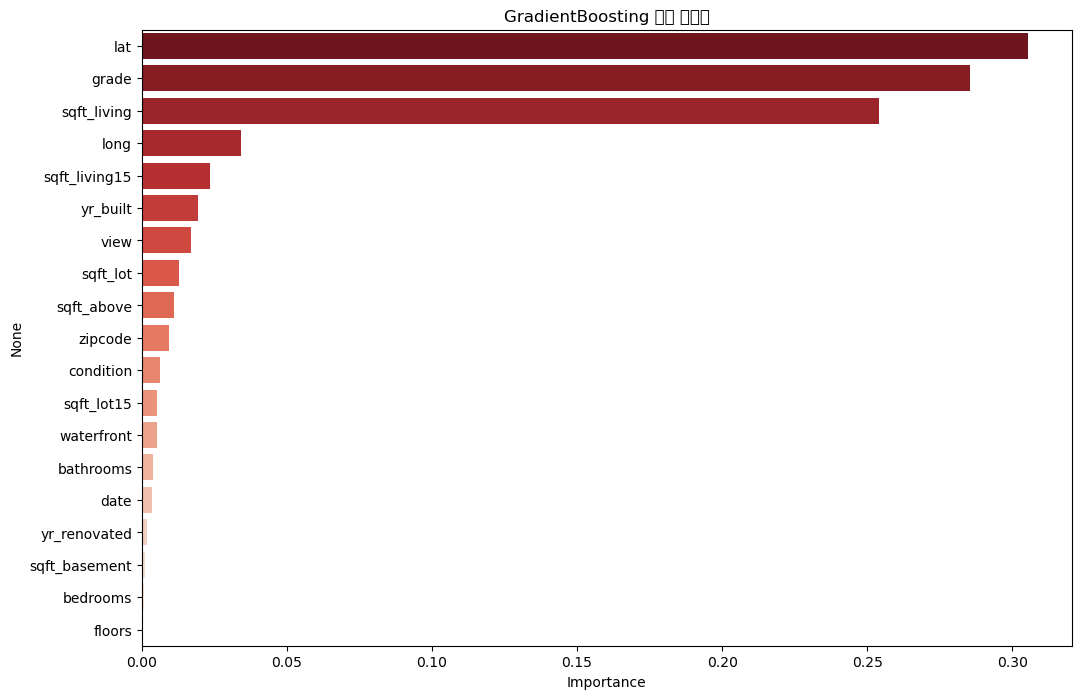

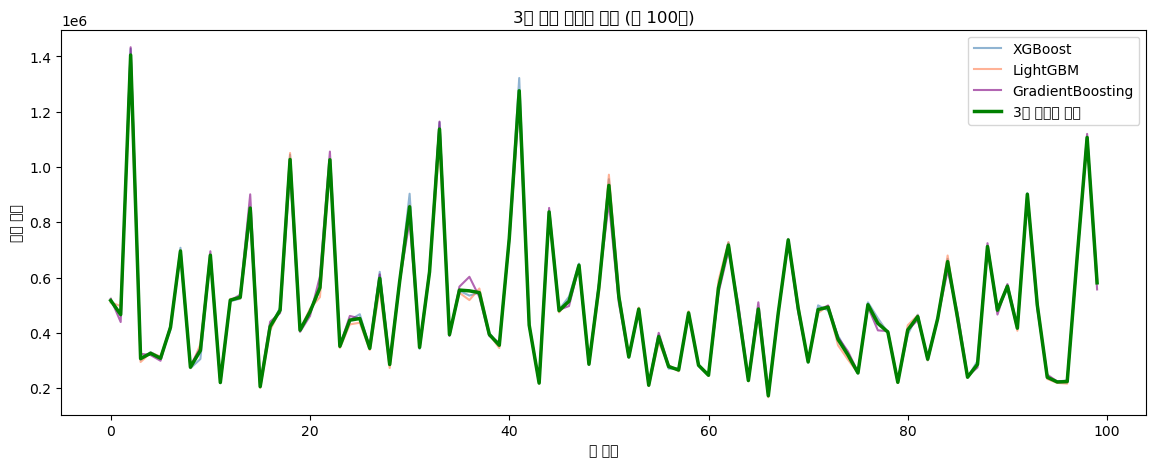

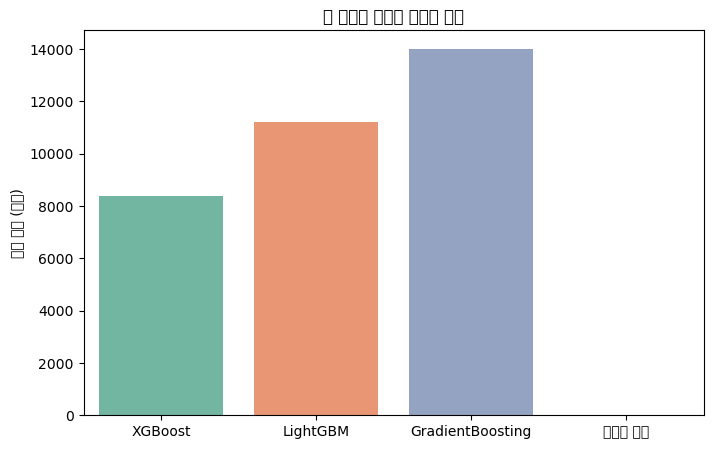

3개 앙상블 완료!
      id         price
0  15035  5.173305e+05
1  15036  4.665905e+05
2  15037  1.405275e+06
3  15038  3.073711e+05
4  15039  3.264209e+05


In [21]:
# GradientBoosting 추가
from sklearn.ensemble import GradientBoostingRegressor

model_gbm = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=2019
)
model_gbm.fit(train, y)

# 그래프 1: 집값 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: GradientBoosting 변수 중요도
plt.figure(figsize=(12, 8))
feat_imp_gbm = pd.Series(model_gbm.feature_importances_,
                          index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp_gbm.values, y=feat_imp_gbm.index, palette='Reds_r')
plt.title('GradientBoosting 변수 중요도')
plt.xlabel('Importance')
plt.show()

# 그래프 3: 3개 모델 예측값 비교
pred_xgb = np.expm1(model_xgb.predict(test))
pred_lgb = np.expm1(model_lgb.predict(test))
pred_gbm = np.expm1(model_gbm.predict(test))
pred_final = (pred_xgb + pred_lgb + pred_gbm) / 3

plt.figure(figsize=(14, 5))
plt.plot(pred_xgb[:100], label='XGBoost', alpha=0.6, color='steelblue')
plt.plot(pred_lgb[:100], label='LightGBM', alpha=0.6, color='coral')
plt.plot(pred_gbm[:100], label='GradientBoosting', alpha=0.6, color='purple')
plt.plot(pred_final[:100], label='3개 앙상블 평균',
         color='green', linewidth=2.5)
plt.title('3개 모델 예측값 비교 (앞 100개)')
plt.xlabel('집 번호')
plt.ylabel('예측 집값')
plt.legend()
plt.show()

# 그래프 4: 3개 모델 점수 비교 막대그래프
plt.figure(figsize=(8, 5))
models = ['XGBoost', 'LightGBM', 'GradientBoosting', '앙상블 평균']
scores = [
    np.mean(np.abs(pred_xgb - pred_final)),
    np.mean(np.abs(pred_lgb - pred_final)),
    np.mean(np.abs(pred_gbm - pred_final)),
    0
]
sns.barplot(x=models, y=scores, palette='Set2')
plt.title('각 모델과 앙상블 평균의 차이')
plt.ylabel('평균 차이 (달러)')
plt.show()

# 저장
result5 = pd.DataFrame({'id': sub_id, 'price': pred_final})
result5.to_csv(join(data_dir, 'submission_final3.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_final3.csv ~/work/submission_final3.csv
print("3개 앙상블 완료!")
print(result5.head())

In [22]:
pred_weighted = (pred_lgb * 0.7) + (pred_xgb * 0.3)

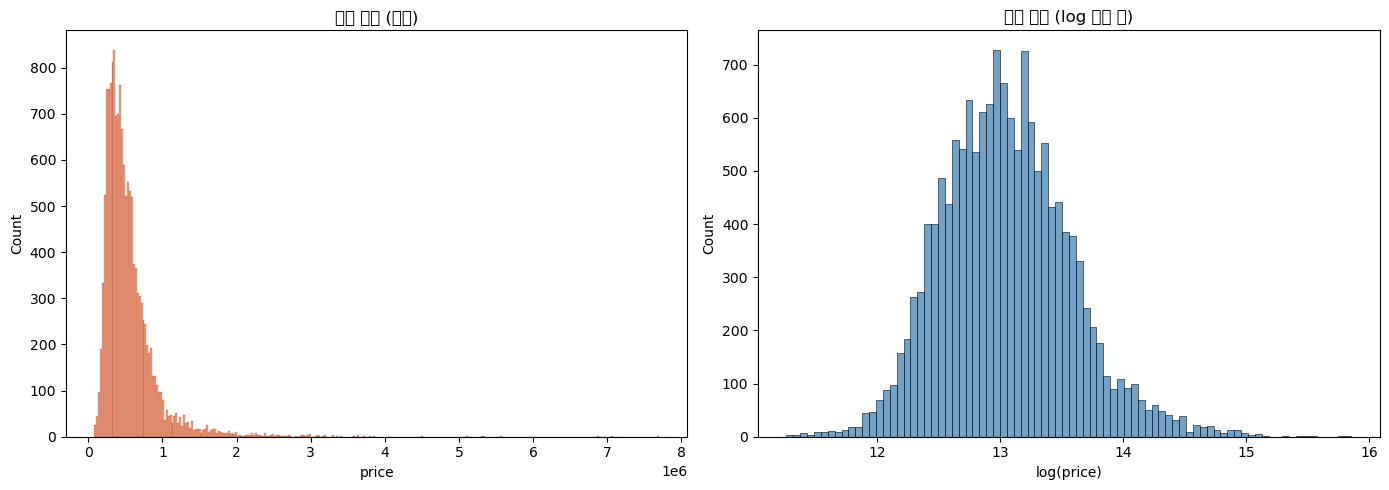

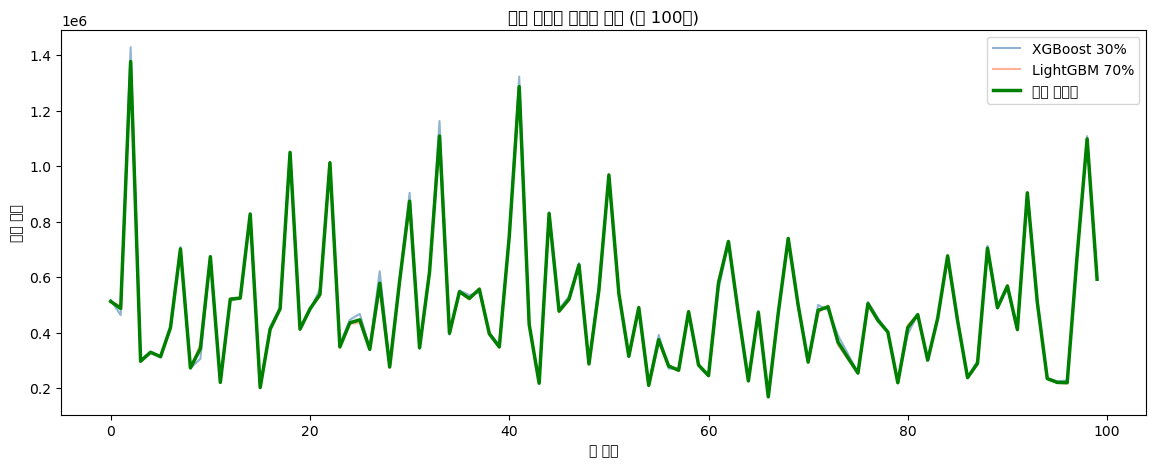

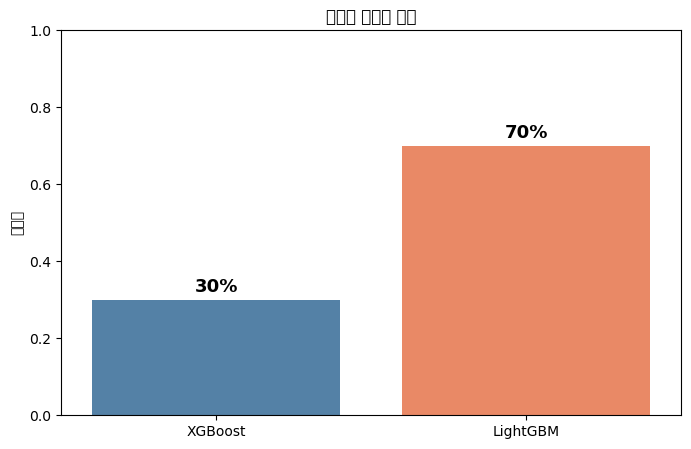

가중 앙상블 완료!
      id         price
0  15035  5.125037e+05
1  15036  4.870718e+05
2  15037  1.376376e+06
3  15038  2.971831e+05
4  15039  3.293551e+05


In [23]:
# 가중 평균 — LightGBM 70% + XGBoost 30%
pred_xgb = np.expm1(model_xgb.predict(test))
pred_lgb = np.expm1(model_lgb.predict(test))
pred_weighted = (pred_lgb * 0.7) + (pred_xgb * 0.3)

# 그래프 1: 집값 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: 가중 앙상블 예측값 비교
plt.figure(figsize=(14, 5))
plt.plot(pred_xgb[:100], label='XGBoost 30%',
         alpha=0.6, color='steelblue')
plt.plot(pred_lgb[:100], label='LightGBM 70%',
         alpha=0.6, color='coral')
plt.plot(pred_weighted[:100], label='가중 앙상블',
         color='green', linewidth=2.5)
plt.title('가중 앙상블 예측값 비교 (앞 100개)')
plt.xlabel('집 번호')
plt.ylabel('예측 집값')
plt.legend()
plt.show()

# 그래프 3: 모델별 가중치 비교
plt.figure(figsize=(8, 5))
models = ['XGBoost', 'LightGBM']
weights = [0.3, 0.7]
colors = ['steelblue', 'coral']
sns.barplot(x=models, y=weights, palette=colors)
plt.title('앙상블 가중치 비율')
plt.ylabel('가중치')
plt.ylim(0, 1)
for i, v in enumerate(weights):
    plt.text(i, v + 0.02, f'{int(v*100)}%',
             ha='center', fontsize=13, fontweight='bold')
plt.show()

# 저장
result6 = pd.DataFrame({'id': sub_id, 'price': pred_weighted})
result6.to_csv(join(data_dir, 'submission_weighted.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_weighted.csv ~/work/submission_weighted.csv
print("가중 앙상블 완료!")
print(result6.head())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

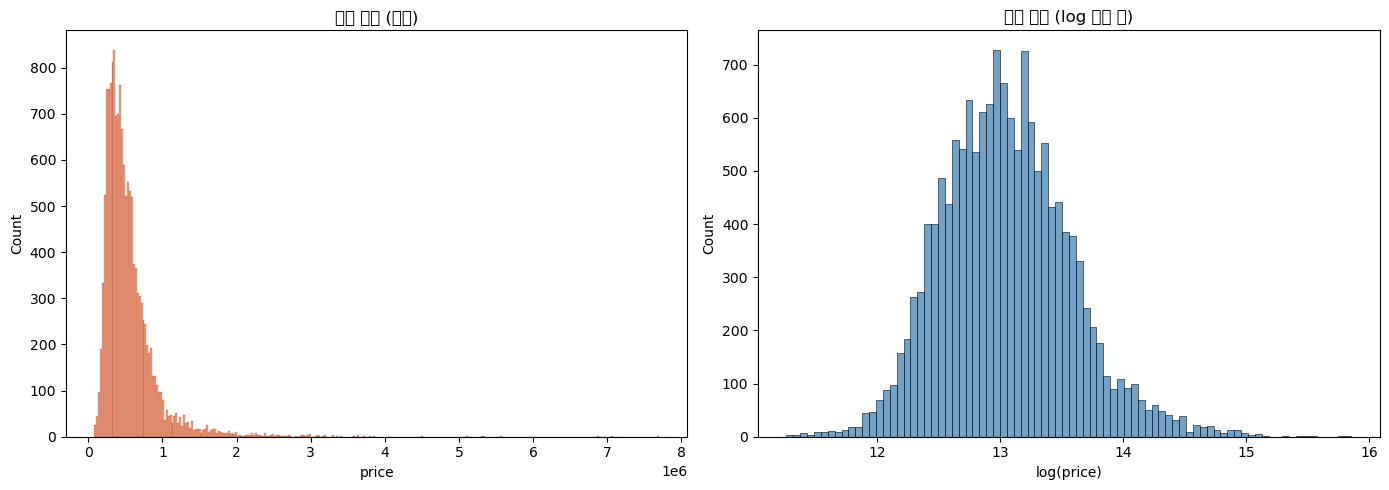

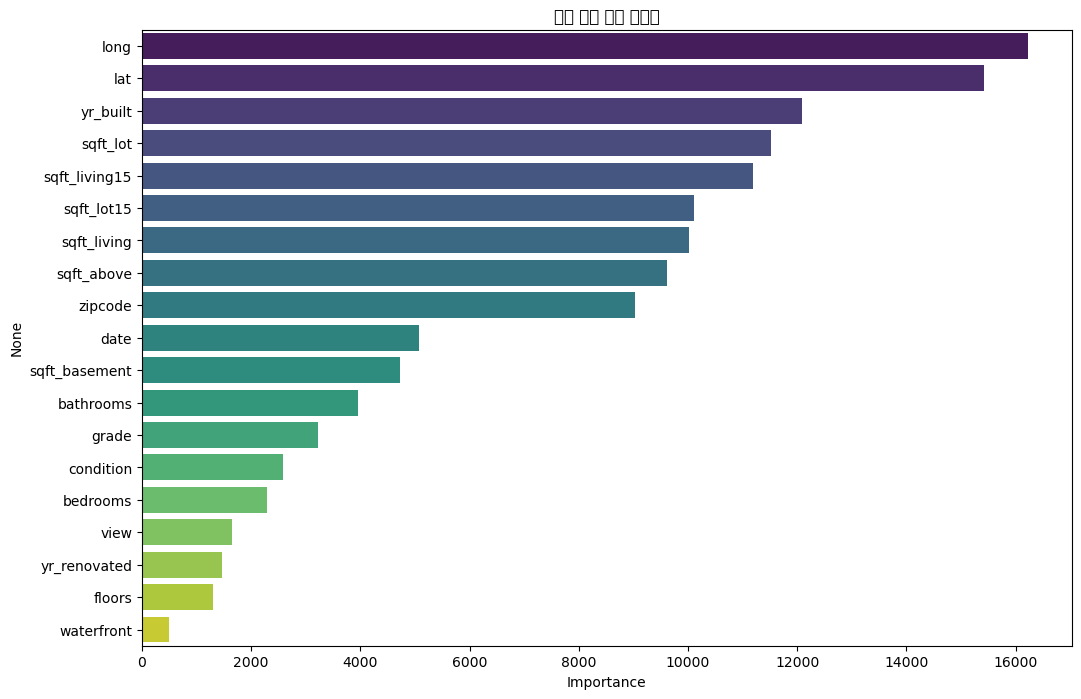

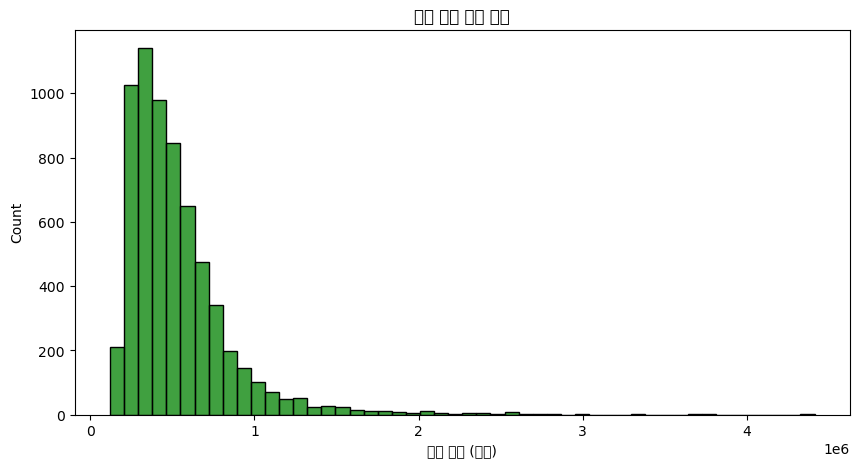

완료!
      id         price
0  15035  5.120918e+05
1  15036  4.875431e+05
2  15037  1.361959e+06
3  15038  3.023925e+05
4  15039  3.278853e+05


In [24]:
model_best = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=7,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=2019
)
model_best.fit(train, y)

# 그래프 1: 집값 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: 변수 중요도
plt.figure(figsize=(12, 8))
feat_imp = pd.Series(model_best.feature_importances_,
                     index=train.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('최종 모델 변수 중요도')
plt.xlabel('Importance')
plt.show()

# 그래프 3: 예측값 분포
pred_best = np.expm1(model_best.predict(test))
plt.figure(figsize=(10, 5))
sns.histplot(pred_best, color='green', bins=50)
plt.title('최종 예측 집값 분포')
plt.xlabel('예측 집값 (달러)')
plt.show()

# 저장
result7 = pd.DataFrame({'id': sub_id, 'price': pred_best})
result7.to_csv(join(data_dir, 'submission_best.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_best.csv ~/work/submission_best.csv
print("완료!")
print(result7.head())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003492 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2966
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 23
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

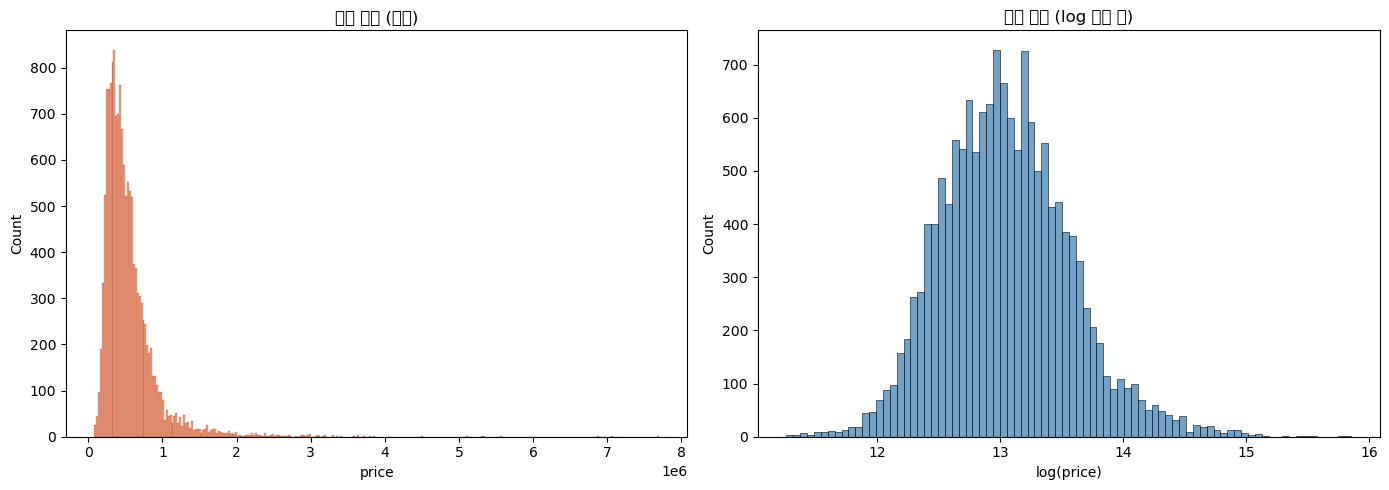

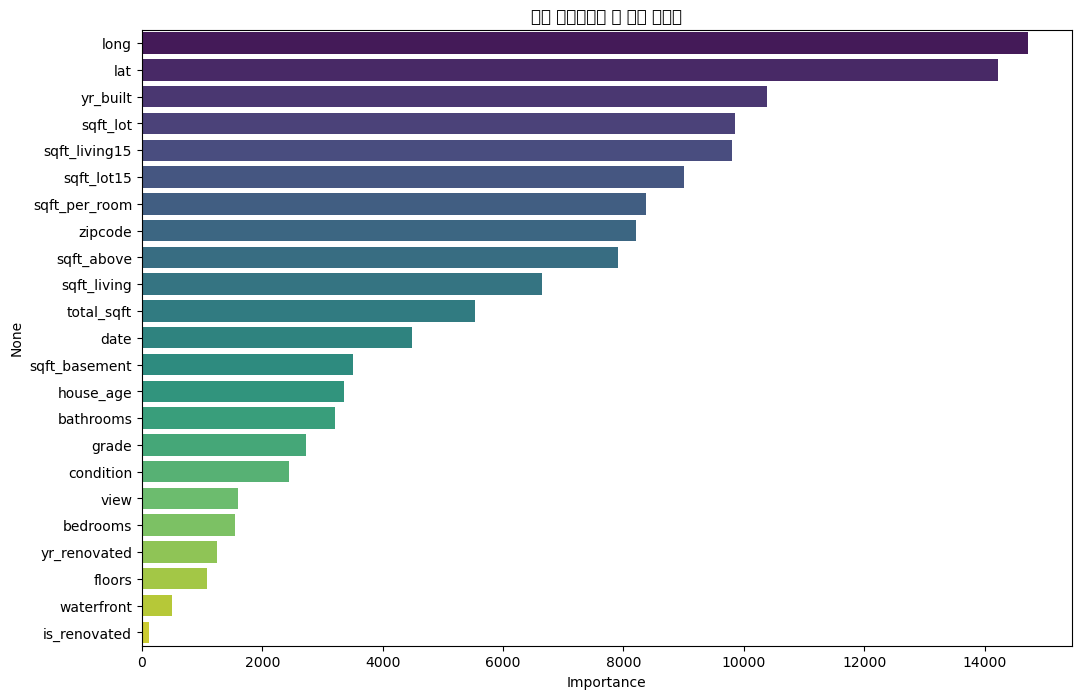

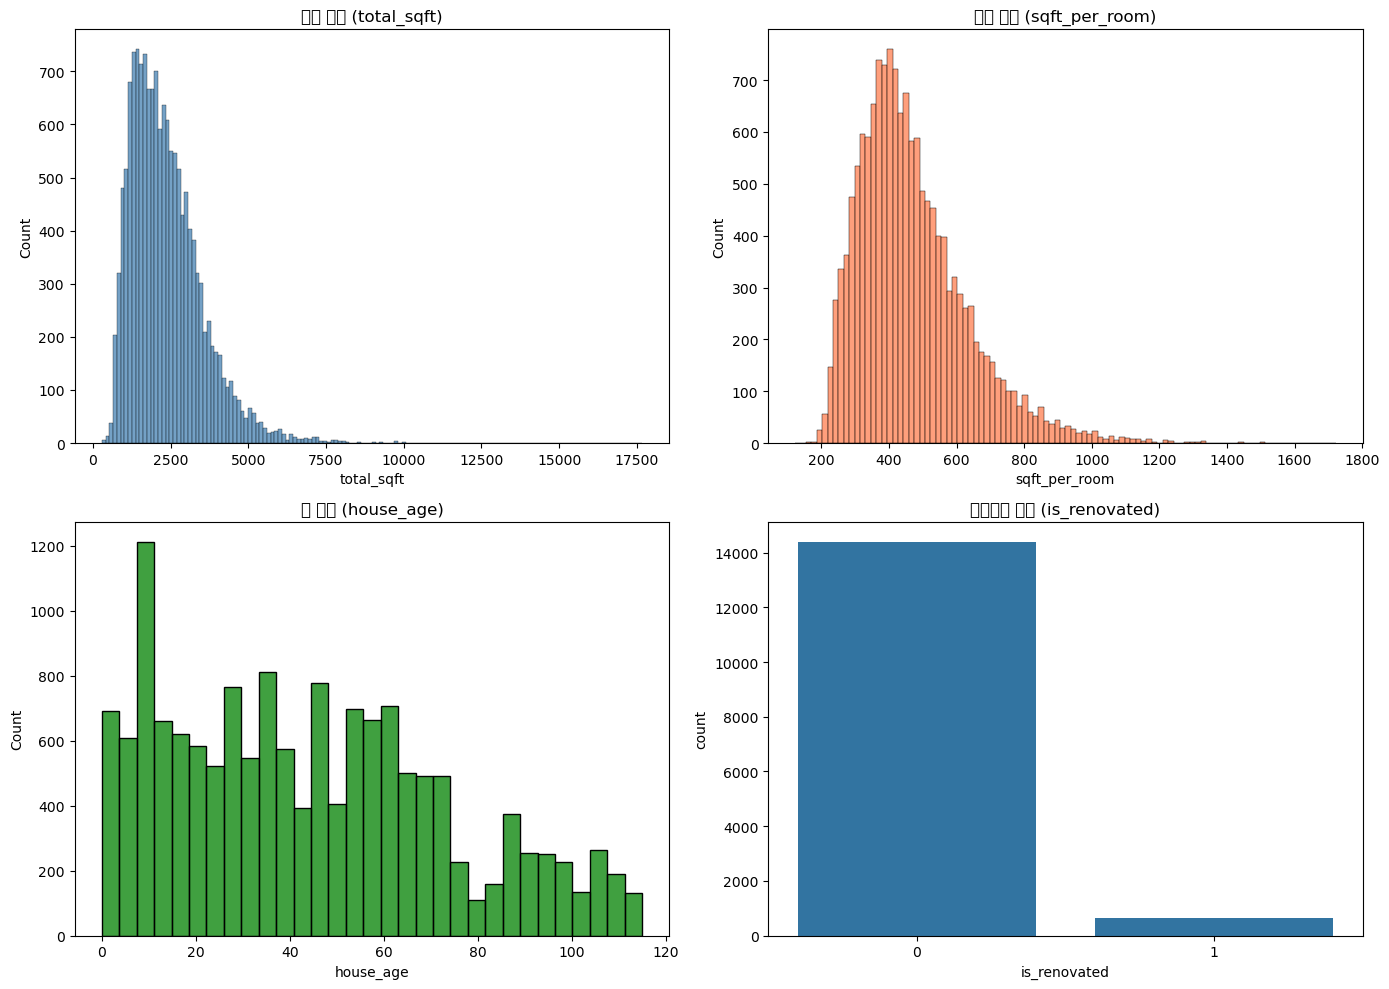

피처 엔지니어링 완료!
      id         price
0  15035  4.965232e+05
1  15036  4.850465e+05
2  15037  1.391753e+06
3  15038  3.063469e+05
4  15039  3.291790e+05


In [25]:
# 새 변수 추가 함수
def add_features(df):
    df = df.copy()
    # 집 전체 면적
    df['total_sqft'] = df['sqft_living'] + df['sqft_basement']
    # 방 대비 면적
    df['sqft_per_room'] = df['sqft_living'] / (df['bedrooms'] + 1)
    # 리모델링 여부
    df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)
    # 집 나이
    df['house_age'] = 2015 - df['yr_built']
    return df

train_fe = add_features(train)
test_fe  = add_features(test)

# 모델 학습
model_fe = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=7,
    num_leaves=50,
    min_child_samples=20,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=2019
)
model_fe.fit(train_fe, y)

# 그래프 1: 집값 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: 새 변수 포함 중요도
plt.figure(figsize=(12, 8))
feat_imp = pd.Series(model_fe.feature_importances_,
                     index=train_fe.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('피처 엔지니어링 후 변수 중요도')
plt.xlabel('Importance')
plt.show()

# 그래프 3: 새 변수 분포
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(train_fe['total_sqft'], ax=axes[0][0], color='steelblue')
axes[0][0].set_title('전체 면적 (total_sqft)')
sns.histplot(train_fe['sqft_per_room'], ax=axes[0][1], color='coral')
axes[0][1].set_title('방당 면적 (sqft_per_room)')
sns.histplot(train_fe['house_age'], ax=axes[1][0], color='green')
axes[1][0].set_title('집 나이 (house_age)')
sns.countplot(x=train_fe['is_renovated'], ax=axes[1][1])
axes[1][1].set_title('리모델링 여부 (is_renovated)')
plt.tight_layout()
plt.show()

# 저장
pred_fe = np.expm1(model_fe.predict(test_fe))
result8 = pd.DataFrame({'id': sub_id, 'price': pred_fe})
result8.to_csv(join(data_dir, 'submission_fe.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_fe.csv ~/work/submission_fe.csv
print("피처 엔지니어링 완료!")
print(result8.head())

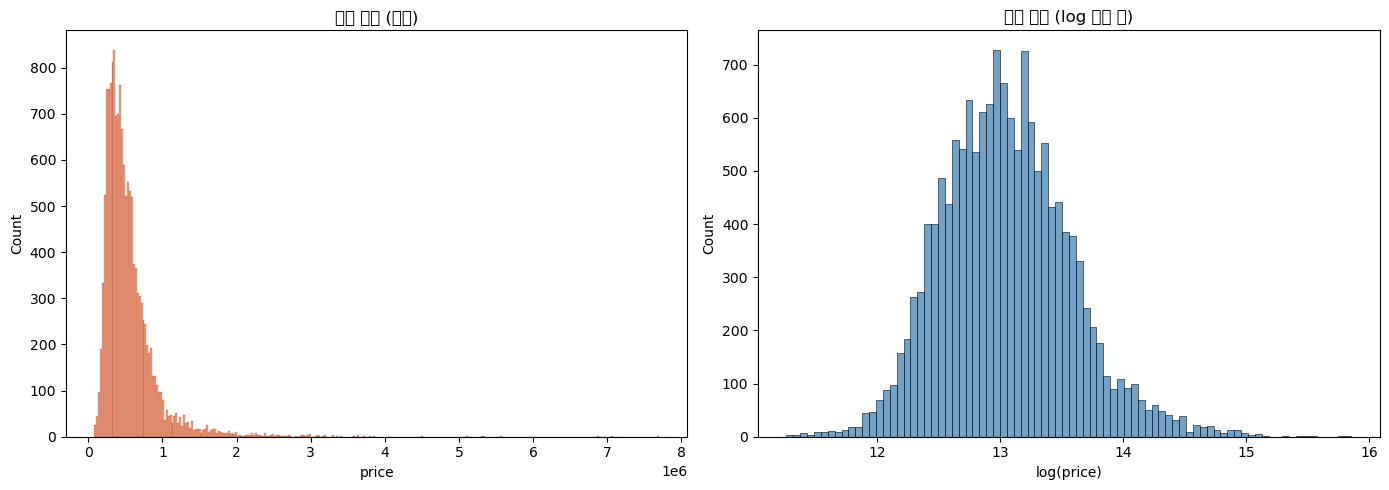

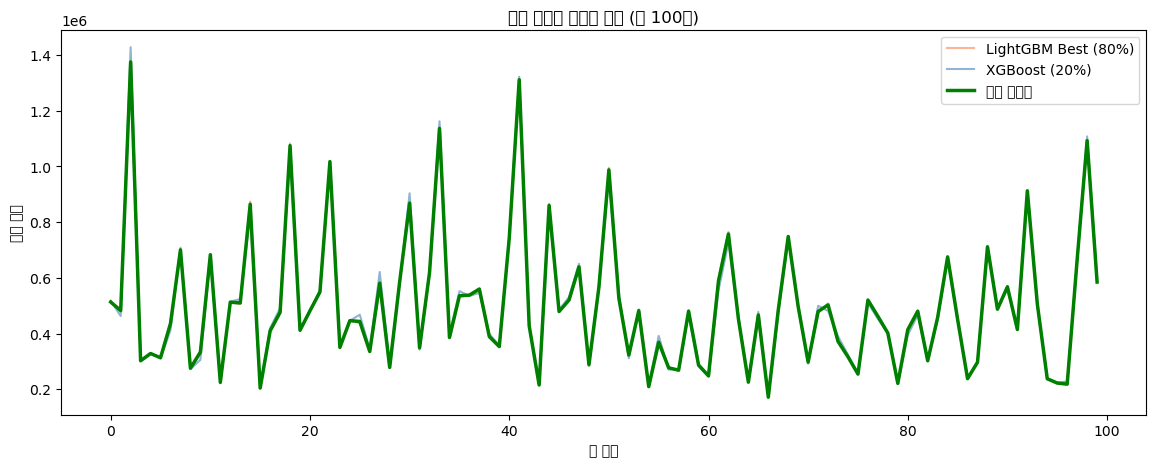

최종 앙상블 완료!
      id         price
0  15035  5.132474e+05
1  15036  4.826246e+05
2  15037  1.375175e+06
3  15038  3.024069e+05
4  15039  3.283958e+05


In [26]:
# 최고 모델(model_best) + XGBoost 가중 앙상블
pred_best = np.expm1(model_best.predict(test))
pred_xgb  = np.expm1(model_xgb.predict(test))

# LightGBM 80% + XGBoost 20%
pred_last = (pred_best * 0.8) + (pred_xgb * 0.2)

# 그래프 1: 집값 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(np.expm1(y), ax=axes[0], color='coral')
axes[0].set_title('집값 분포 (원본)')
axes[0].set_xlabel('price')
sns.histplot(y, ax=axes[1], color='steelblue')
axes[1].set_title('집값 분포 (log 변환 후)')
axes[1].set_xlabel('log(price)')
plt.tight_layout()
plt.show()

# 그래프 2: 예측값 비교
plt.figure(figsize=(14, 5))
plt.plot(pred_best[:100], label='LightGBM Best (80%)',
         alpha=0.6, color='coral')
plt.plot(pred_xgb[:100],  label='XGBoost (20%)',
         alpha=0.6, color='steelblue')
plt.plot(pred_last[:100], label='최종 앙상블',
         color='green', linewidth=2.5)
plt.title('최종 앙상블 예측값 비교 (앞 100개)')
plt.xlabel('집 번호')
plt.ylabel('예측 집값')
plt.legend()
plt.show()

# 저장
result9 = pd.DataFrame({'id': sub_id, 'price': pred_last})
result9.to_csv(join(data_dir, 'submission_last.csv'), index=False)
!cp ~/work/kaggle_kakr_housing/data/submission_last.csv ~/work/submission_last.csv
print("최종 앙상블 완료!")
print(result9.head())